In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from src.base_builder import cohort_builder, chain_ladder, segment_weighted_avg, gamma_fitting, unbias_calibration
from src.plot_function import plot_lifetime, plot_lifetime_avg, plot_lifetime_comp, plot_unbias_lifetime
from src.stats_testing import lifetime_ks

warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import cohort
df = pd.read_parquet(
    '../data/processed/cohort_count.parquet',
    engine = 'pyarrow'
)

# Show table
df.head(5)

,segment,date,times,n,bad
0,segment_0,2014-01-31,2,1,0
1,segment_0,2014-01-31,4,9,6
2,segment_0,2014-01-31,5,19,9
3,segment_0,2014-01-31,6,18,11
4,segment_0,2014-01-31,7,11,4


In [4]:
# Import unbias
unbias_odr = pd.read_parquet(
    '../data/processed/unbias_odr.parquet',
    engine = 'pyarrow'
)

# Show table
unbias_odr

,segment,n,bad,odr,good,cum_bad,cum_good,roc,ks
5,segment_3,739,640,0.866035,99.0,0.023371,0.000176,0.000002,0.023196
3,segment_11,4531,2432,0.536747,2099.0,0.112182,0.003897,0.000252,0.108285
4,segment_2,3494,1625,0.465083,1869.0,0.171524,0.007210,0.000470,0.164313
2,segment_10,26408,7365,0.278893,19043.0,0.440476,0.040972,0.010331,0.399504
1,segment_1,18133,3135,0.172889,14998.0,0.554959,0.067562,0.013234,0.487397
11,segment_9,38786,4923,0.126927,33863.0,0.734736,0.127598,0.038714,0.607137
10,segment_8,55294,2090,0.037798,53204.0,0.811058,0.221924,0.072904,0.589133
0,segment_0,125102,3595,0.028737,121507.0,0.942339,0.437345,0.188859,0.504993
9,segment_7,58612,804,0.013717,57808.0,0.971699,0.539834,0.098083,0.431865
8,segment_6,79047,366,0.004630,78681.0,0.985064,0.679328,0.136479,0.305736


In [5]:
# Constant parameters
DATE_COL = "date" #Date key
SEGMENT_COL = "segment" #Segmentation column
DEFAULT_FLAG = 4 #Any values greater than this value will be considered as default
END_DATE = df["date"].max()
COHORT_LEVEL = "Yearly" #"Yearly" or "Monthly"
ODR_LEVEL = "Yearly" #"Yearly" or "Monthly"

# =============================================== #
# Segmentation pools:                             #
# pool_1: ["segment_0"]                           #
# pool_2: ["segment_1", "segment_2", "segment_3"] #
# pool_3: ["segment_4"]                           #
# pool_3: ["segment_5"]                           #
# pool_4: ["segment_6"]                           #
# pool_5: ["segment_7", "segmnet_8"]              #
# pool_6: ["segment_9"]                           #
# pool_7: ["segment_10", "segmnet_11"]            #
# =============================================== #

In [6]:
# Grouping segments for cohort building
POOL = [
    ["segment_0"],
    ["segment_1", "segment_2", "segment_3"],
    ["segment_4"],
    ["segment_5"],
    ["segment_6"],
    ["segment_7", "segment_8"],
    ["segment_9"],
    ["segment_10", "segment_11"],
]

# Cohort building
cumulative_odr = cohort_builder(
    df = df,
    date_col = DATE_COL,
    end_date = END_DATE,
    segment_col = SEGMENT_COL,
    pool = POOL,
    cohort_level = COHORT_LEVEL,
    odr_level = ODR_LEVEL
    )

=== Processing ===
[Cohort building]
    [✓] Pool 0: Segment - ['segment_0']
    [✓] Pool 1: Segment - ['segment_1', 'segment_2', 'segment_3']
    [✓] Pool 2: Segment - ['segment_4']
    [✓] Pool 3: Segment - ['segment_5']
    [✓] Pool 4: Segment - ['segment_6']
    [✓] Pool 5: Segment - ['segment_7', 'segment_8']
    [✓] Pool 6: Segment - ['segment_9']
    [✓] Pool 7: Segment - ['segment_10', 'segment_11']


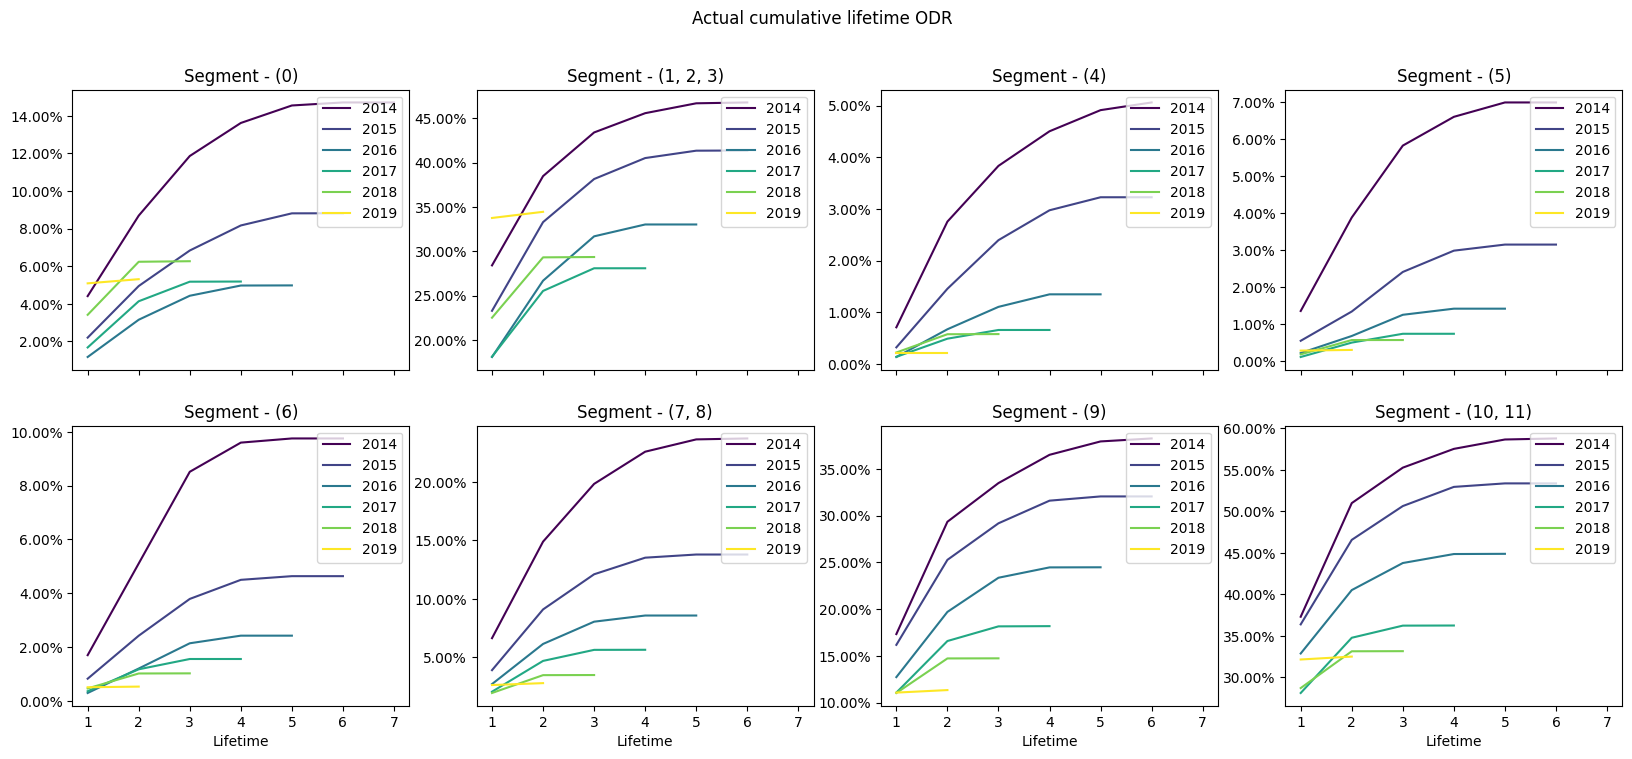

In [7]:
# Plot actual cumulative lifetime ODR
plot_lifetime(
    data = cumulative_odr,
    plot_title = "Actual cumulative lifetime ODR"
)

In [8]:
# Save actual cumulative lifetime ODR result
with open('../model/actual_cumulative_odr.pkl', 'wb') as f:
    pickle.dump(cumulative_odr, f)

In [9]:
# Chain-Ladder
cumulative_chain = chain_ladder(data = cumulative_odr)

=== Processing ===
[Chain-Ladder by development factor]
    [✓] Pool 0: Segment - ('segment_0',)
    [✓] Pool 1: Segment - ('segment_1', 'segment_2', 'segment_3')
    [✓] Pool 2: Segment - ('segment_4',)
    [✓] Pool 3: Segment - ('segment_5',)
    [✓] Pool 4: Segment - ('segment_6',)
    [✓] Pool 5: Segment - ('segment_7', 'segment_8')
    [✓] Pool 6: Segment - ('segment_9',)
    [✓] Pool 7: Segment - ('segment_10', 'segment_11')


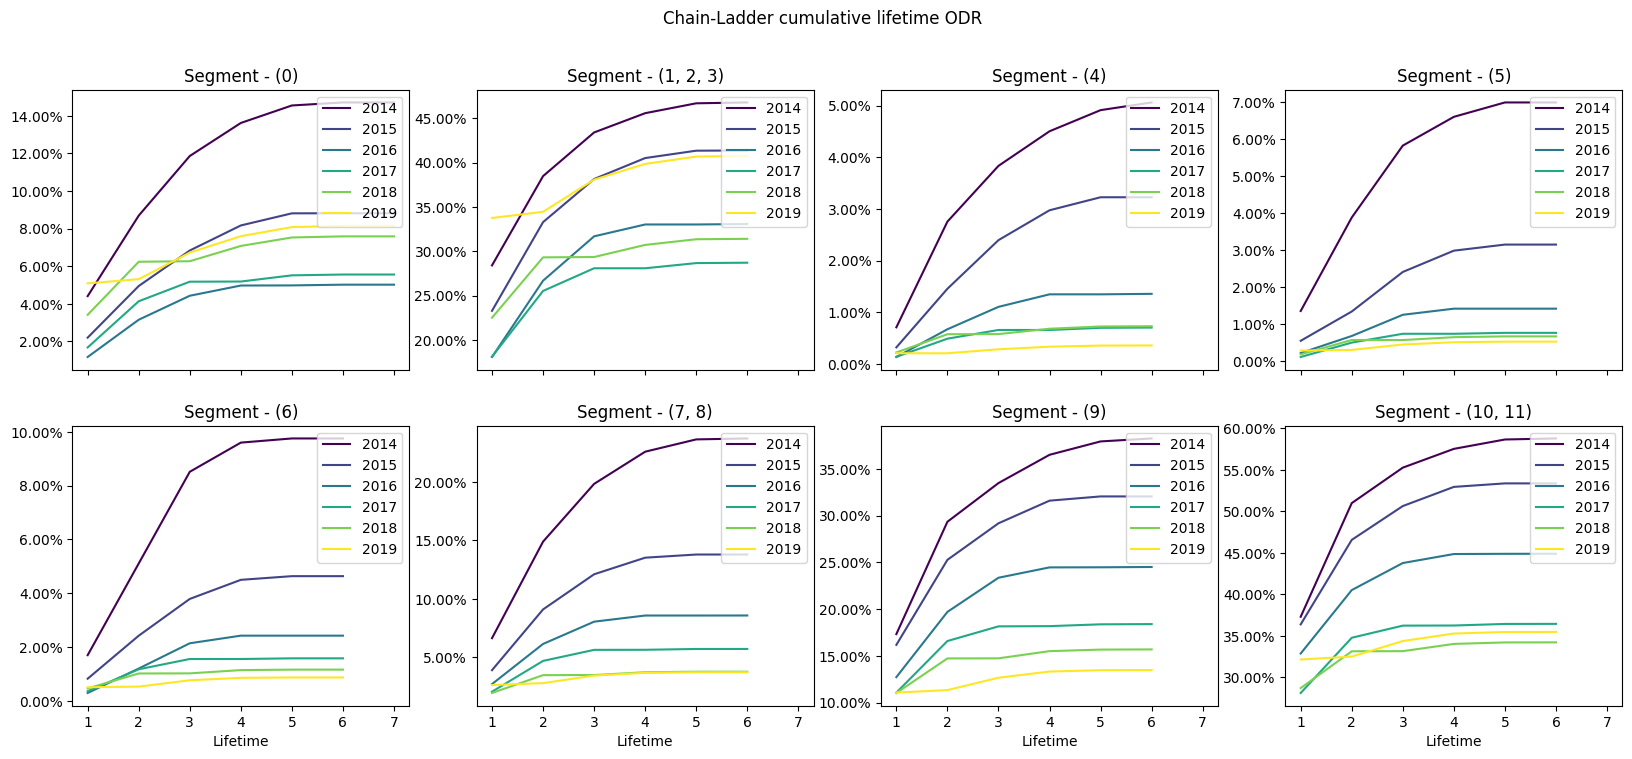

In [10]:
# Plot Chain-Ladder cumulative lifetime ODR
plot_lifetime(
    data = cumulative_chain,
    plot_title = "Chain-Ladder cumulative lifetime ODR"
)

In [11]:
# Save Chain-Ladder cumulative lifetime ODR result
with open('../model/chain_cumulative_odr.pkl', 'wb') as f:
    pickle.dump(cumulative_chain, f)

In [12]:
# Weighted average by segment
weighted_cumulative_odr = segment_weighted_avg(data = cumulative_chain)

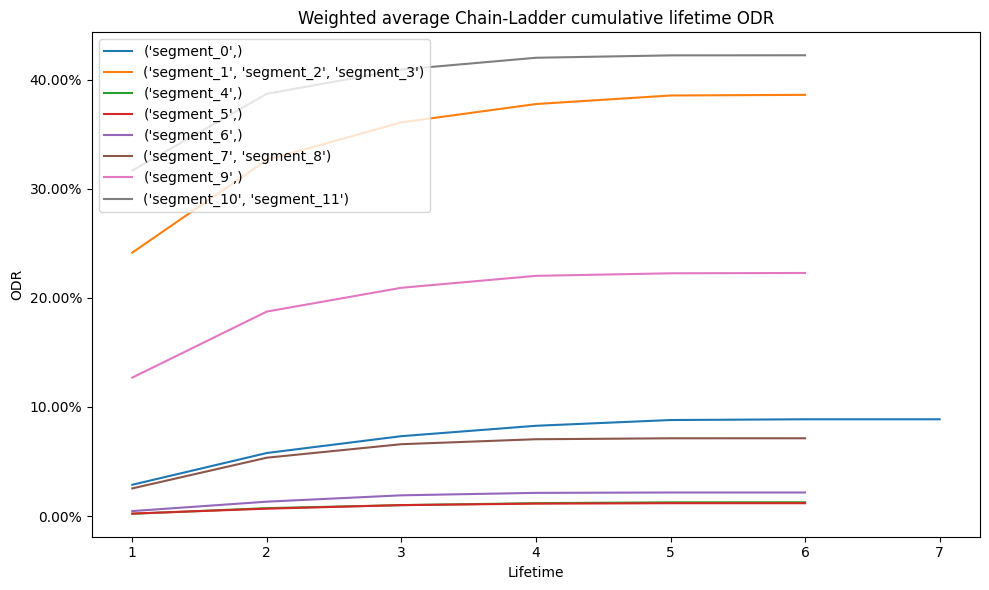

In [13]:
# Plot weighted average Chain-Ladder cumulative lifetime ODR
plot_lifetime_avg(
    data = weighted_cumulative_odr,
    plot_title = "Weighted average Chain-Ladder cumulative lifetime ODR"
)

In [14]:
# Save weighted average Chain-Ladder cumulative lifetime ODR result
with open('../model/w_avg_chain_cumulative_odr.pkl', 'wb') as f:
    pickle.dump(weighted_cumulative_odr, f)

In [15]:
# Gamma curve fitting
gamma_cumulative_odr, gamma_parameters = gamma_fitting(
    data = weighted_cumulative_odr,
    n = 10,
    odr_level = ODR_LEVEL
) #10-years extrapolation

=== Processing ===
[Gamma distribution fitting]
    [✓] Pool 0: Segment - ('segment_0',)
    [✓] Pool 1: Segment - ('segment_1', 'segment_2', 'segment_3')
    [✓] Pool 2: Segment - ('segment_4',)
    [✓] Pool 3: Segment - ('segment_5',)
    [✓] Pool 4: Segment - ('segment_6',)
    [✓] Pool 5: Segment - ('segment_7', 'segment_8')
    [✓] Pool 6: Segment - ('segment_9',)
    [✓] Pool 7: Segment - ('segment_10', 'segment_11')


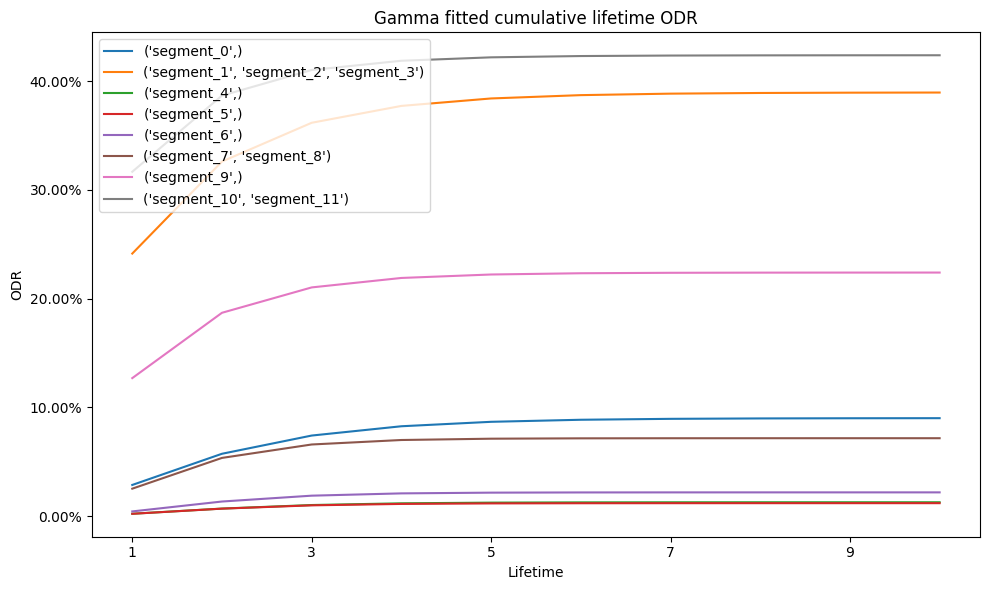

In [16]:
# Plot Gamma fitted cumulative lifetime ODR
plot_lifetime_avg(
    data = gamma_cumulative_odr,
    plot_title = "Gamma fitted cumulative lifetime ODR"
)

In [17]:
# Save Gamma cumulative lifetime ODR result
with open('../model/w_avg_gamma_cumulative_odr.pkl', 'wb') as f:
    pickle.dump(gamma_cumulative_odr, f)

# Save Gamma cumulative lifetime ODR Parameter
with open('../model/w_avg_gamma_parameters.pkl', 'wb') as f:
    pickle.dump(gamma_parameters, f)

In [18]:
# Gamma paramters results
print("=== Result ===\n[Gamma distribution parameters]")
for i, (pool, param) in enumerate(gamma_parameters.items()):
    print(f"Pool {i}: Segment - {pool}")
    print(" ".join(f"    {name}: {val:.4f}" for name, val in zip(["Alpha", "Beta", "Constant"], param)))

=== Result ===
[Gamma distribution parameters]
Pool 0: Segment - ('segment_0',)
    Alpha: 1.7143     Beta: 1.0866     Constant: 0.0902
Pool 1: Segment - ('segment_1', 'segment_2', 'segment_3')
    Alpha: 0.8335     Beta: 1.2917     Constant: 0.3896
Pool 2: Segment - ('segment_4',)
    Alpha: 2.9373     Beta: 0.7116     Constant: 0.0129
Pool 3: Segment - ('segment_5',)
    Alpha: 3.1115     Beta: 0.6368     Constant: 0.0120
Pool 4: Segment - ('segment_6',)
    Alpha: 3.2286     Beta: 0.5826     Constant: 0.0220
Pool 5: Segment - ('segment_7', 'segment_8')
    Alpha: 2.4024     Beta: 0.6291     Constant: 0.0717
Pool 6: Segment - ('segment_9',)
    Alpha: 1.2083     Beta: 0.9439     Constant: 0.2240
Pool 7: Segment - ('segment_10', 'segment_11')
    Alpha: 0.6687     Beta: 1.1028     Constant: 0.4238


In [19]:
# Back-testing --> KS-Test (Pool level)
ks_test_result = lifetime_ks(actual = weighted_cumulative_odr, fitted = gamma_cumulative_odr)

=== Processing ===
[KS Test for Gamma fitted curves]
    [✓] Pool 0: Segment - ('segment_0',)
    [✓] Pool 1: Segment - ('segment_1', 'segment_2', 'segment_3')
    [✓] Pool 2: Segment - ('segment_4',)
    [✓] Pool 3: Segment - ('segment_5',)
    [✓] Pool 4: Segment - ('segment_6',)
    [✓] Pool 5: Segment - ('segment_7', 'segment_8')
    [✓] Pool 6: Segment - ('segment_9',)
    [✓] Pool 7: Segment - ('segment_10', 'segment_11')


In [20]:
# KS Test results
print("=== Result ===\n[KS Test]")
for i, (pool, d) in enumerate(ks_test_result.items()):
    print(f"Pool {i}: Segment - {pool}")
    print(
        f"n: {d["n"]} "
        f"KS-Stat: {float(d["KS-Stat"]):.4f} "
        f"D-Critical: {d["D-Critical"]} "
        f"Result: {d["Result"]}"
    )

=== Result ===
[KS Test]
Pool 0: Segment - ('segment_0',)
n: 7 KS-Stat: 0.1429 D-Critical: 0.483 Result: Pass
Pool 1: Segment - ('segment_1', 'segment_2', 'segment_3')
n: 6 KS-Stat: 0.1667 D-Critical: 0.519 Result: Pass
Pool 2: Segment - ('segment_4',)
n: 6 KS-Stat: 0.1667 D-Critical: 0.519 Result: Pass
Pool 3: Segment - ('segment_5',)
n: 6 KS-Stat: 0.1667 D-Critical: 0.519 Result: Pass
Pool 4: Segment - ('segment_6',)
n: 6 KS-Stat: 0.1667 D-Critical: 0.519 Result: Pass
Pool 5: Segment - ('segment_7', 'segment_8')
n: 6 KS-Stat: 0.1667 D-Critical: 0.519 Result: Pass
Pool 6: Segment - ('segment_9',)
n: 6 KS-Stat: 0.1667 D-Critical: 0.519 Result: Pass
Pool 7: Segment - ('segment_10', 'segment_11')
n: 6 KS-Stat: 0.1667 D-Critical: 0.519 Result: Pass


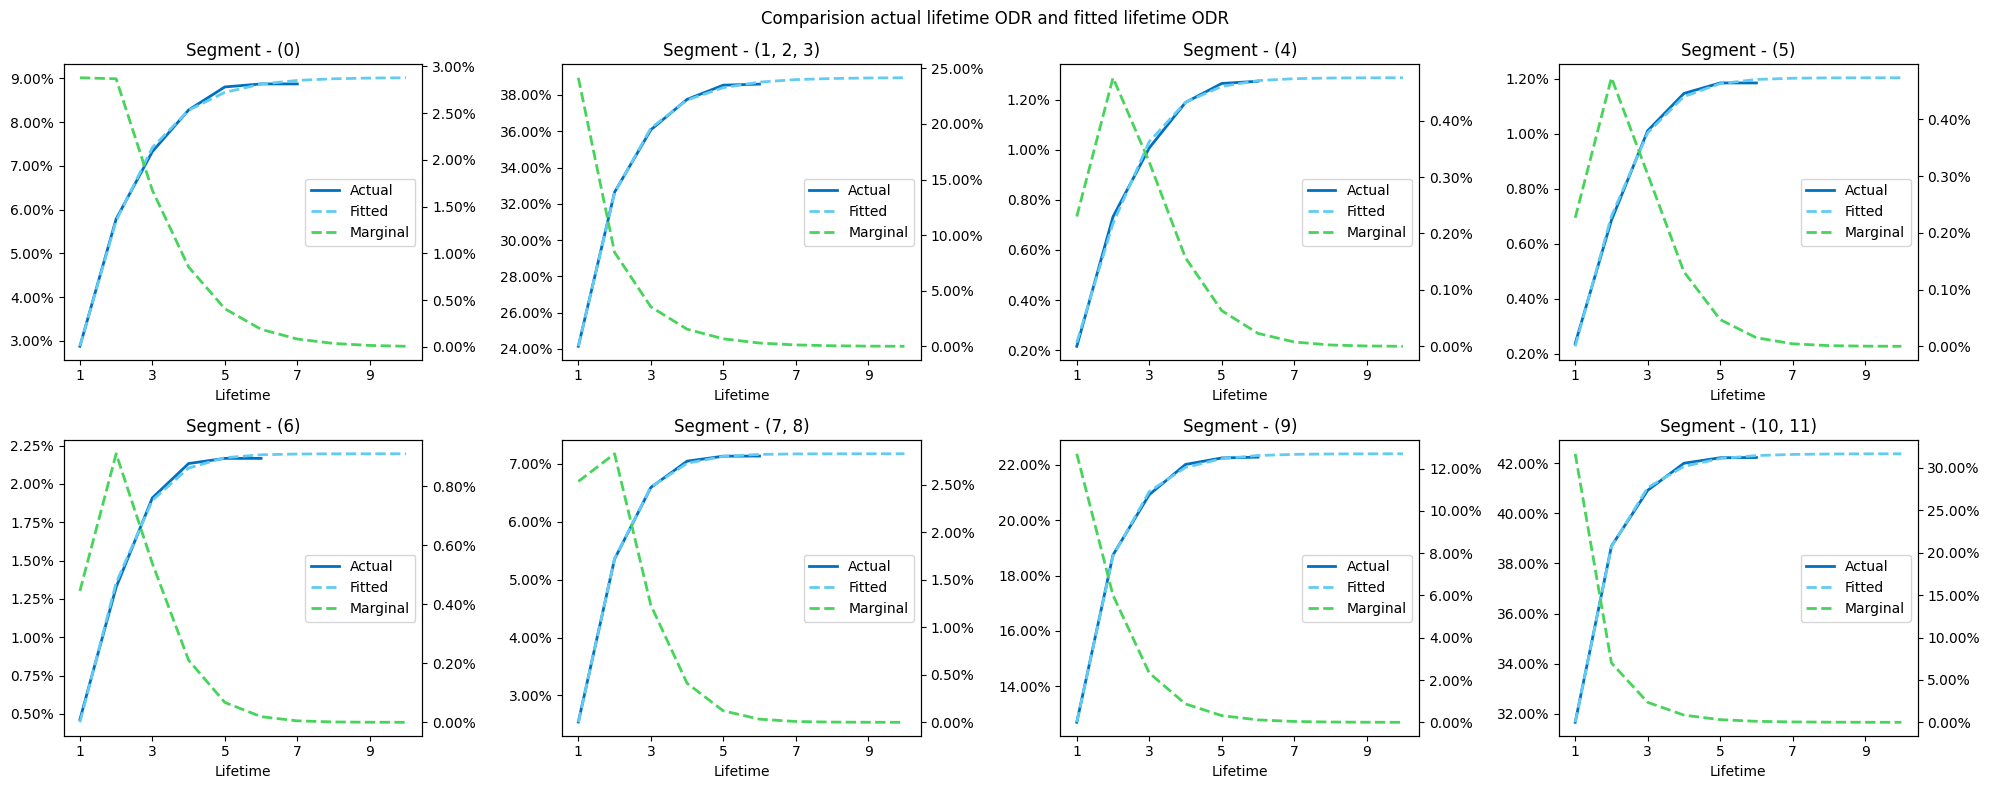

In [21]:
# Plot comparision actual lifetime ODR and fitted lifetime ODR
plot_lifetime_comp(
    actual = weighted_cumulative_odr,
    fitted = gamma_cumulative_odr,
    plot_title = "Comparision actual lifetime ODR and fitted lifetime ODR"
)

## Unbias curves calibration
### Odds function
The ODR Calibration is based on the concept that ratio of odds ratio for month `m` or year `y` and `12 months` or `1-year` will remain the same shape for segmentation level and the lifetime pool level. The equation below is for ODR Calibration of odds function:

$$
\frac{
PD_{bucket}\,\frac{PD_{ttc}}{PD_{target}}
}{
PD_{bucket}\,\frac{PD_{ttc}}{PD_{target}}
\;+\;
(1 - PD_{bucket})\,\frac{1 - PD_{ttc}}{1 - PD_{target}}
}
$$

where;
- `P_{ttc}`     are TTC PD(s) in month `m` or year `y` for a corresponding to the pool;
- `P_{bucket}`  is a 12-months PD for a segmentation;
- `P_{target}`  is a PD at month of 12 when monthly level or at year of 1 when yearly level for a corresponding to the pool

In [22]:
# Unbias calibration
unbias_cumulative_odr = unbias_calibration(
    lifetime_data = gamma_cumulative_odr,
    unbias_data = unbias_odr,
    unbias_segment_col = "segment",
    unbias_odr_col = "odr",
    n_col = "n"
)

=== Processing ===
[12-months unbias ODR Calibration]
    [✓] Segment - segment_0
    [✓] Segment - segment_1
    [✓] Segment - segment_2
    [✓] Segment - segment_3
    [✓] Segment - segment_4
    [✓] Segment - segment_5
    [✓] Segment - segment_6
    [✓] Segment - segment_7
    [✓] Segment - segment_8
    [✓] Segment - segment_9
    [✓] Segment - segment_10
    [✓] Segment - segment_11


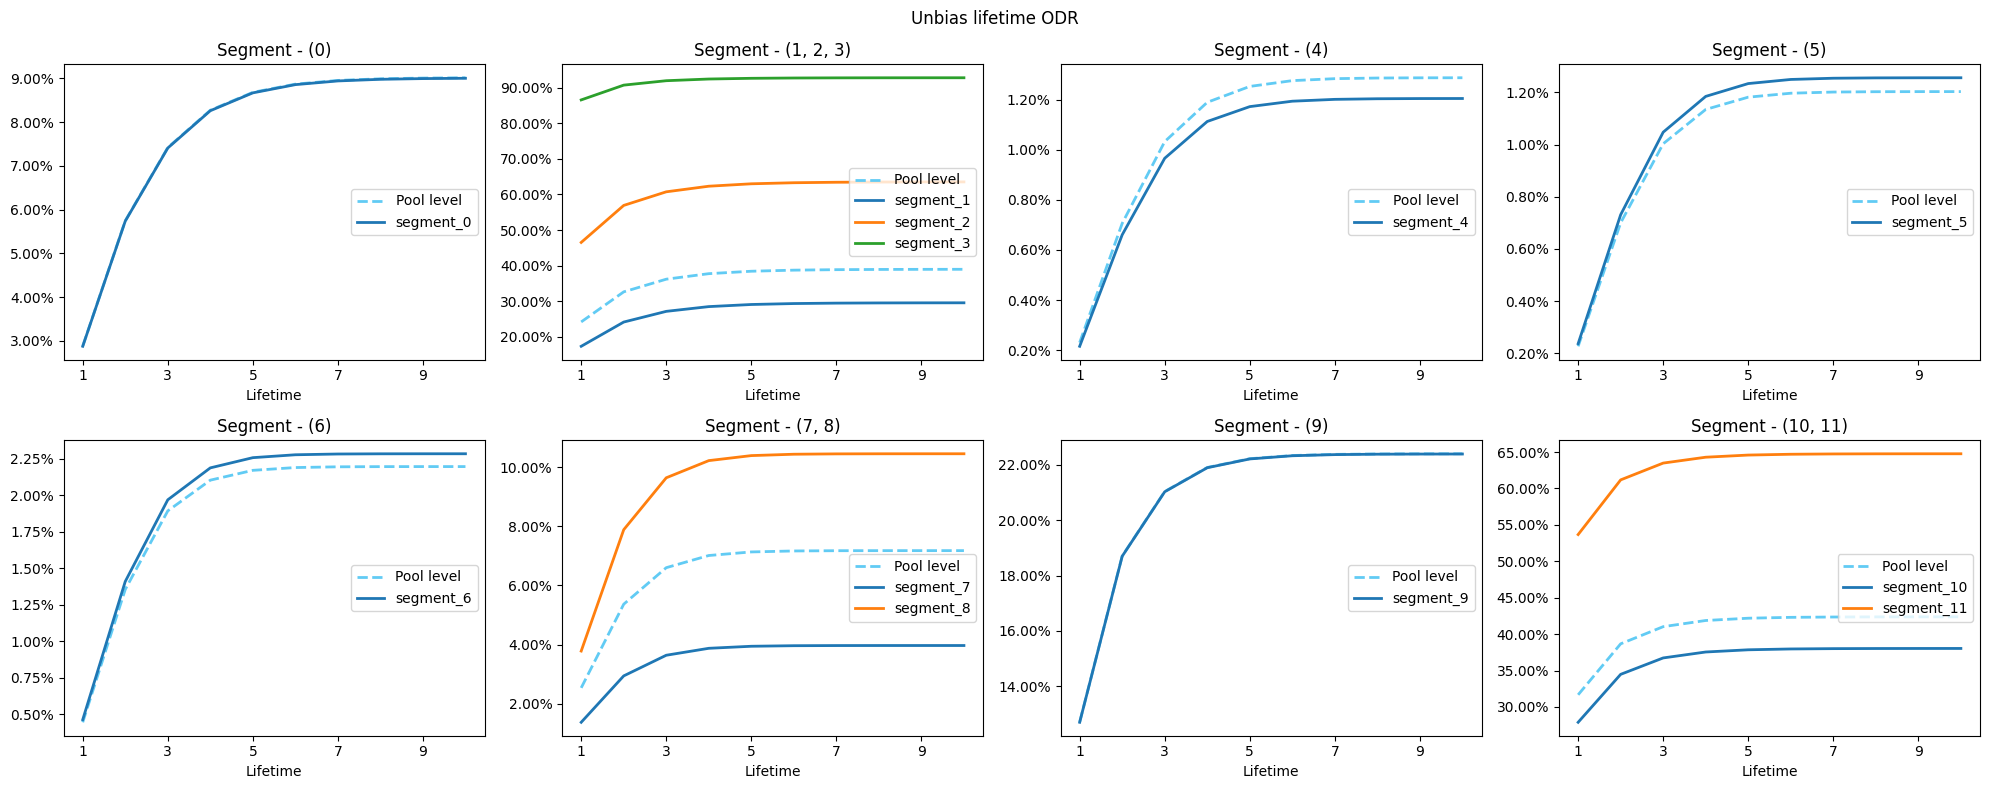

In [23]:
# Plot unbias lifetime ODR
plot_unbias_lifetime(
    fitted = gamma_cumulative_odr,
    unbias = unbias_cumulative_odr,
    plot_title = "Unbias lifetime ODR"
)

In [24]:
# Save unbias cumulative lifetime ODR result
with open('../model/unbias_cumulative_odr.pkl', 'wb') as f:
    pickle.dump(unbias_cumulative_odr, f)